# Entrenamiento de Regresión Ridge - ODEPA

Este notebook contiene el pipeline de entrenamiento y evaluación del modelo de **Regresión Ridge** como línea base lineal para predecir el precio promedio por kilogramo de productos agrícolas, utilizando la división cronológica de los datos.

Para garantizar el óptimo comportamiento del modelo lineal:
- Se aplica **One-Hot Encoding** a las variables de baja cardinalidad (Subsector, Estacion).
- Se aplica **Target Encoding** a las de alta cardinalidad (Producto, Variedad / Tipo, Calidad, Origen, Mercado).
- Se aplica **StandardScaler** para estandarizar las características numéricas, asegurando que todas las variables contribuyan equitativamente a la penalización L2.

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Carga del Dataset

In [2]:
# Cargar los conjuntos de datos en su ruta correcta
df_train = pd.read_csv("dataset/processed/dataset_entrenamiento.csv")
df_test = pd.read_csv("dataset/processed/dataset_prueba.csv")

print(f"Dataset de entrenamiento (2025): {df_train.shape[0]} registros")
print(f"Dataset de prueba (2026 - 2a mitad): {df_test.shape[0]} registros")

Dataset de entrenamiento (2025): 144018 registros
Dataset de prueba (2026 - 2a mitad): 27374 registros


## 3. Definición de Variables Predictoras y Objetivo

In [3]:
# Lista de variables predictoras seleccionadas
features = [
    "Mercado",
    "Subsector",
    "Producto",
    "Variedad / Tipo",
    "Calidad",
    "Origen",
    "Volumen_Limpio",
    "weight_kg",
    "Mes",
    "Dia_Semana",
    "Estacion"
]

target = "Precio_Promedio_Por_Kilo"

## 4. Separación de X e y

In [4]:
X_train = df_train[features]
y_train = df_train[target]
X_test = df_test[features]
y_test = df_test[target]

## 5. Validación de la Partición

In [5]:
print(f"Dimensiones de X_train: {X_train.shape} | X_test: {X_test.shape}")

Dimensiones de X_train: (144018, 11) | X_test: (27374, 11)


## 6. Identificación de Variables para Preprocesamiento

In [6]:
# Categóricas de baja cardinalidad (para One-Hot Encoding)
cat_baja = ["Subsector", "Estacion"]

# Categóricas de alta cardinalidad (para Target Encoding)
cat_alta = ["Mercado", "Producto", "Variedad / Tipo", "Calidad", "Origen"]

# Variables numéricas (para Normalización/Escalado)
numeric_features = [
    "Volumen_Limpio",
    "weight_kg",
    "Mes",
    "Dia_Semana"
]

## 7. Creación del Preprocesador

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat_baja",
            OneHotEncoder(handle_unknown="ignore"),
            cat_baja
        ),
        (
            "cat_alta",
            TargetEncoder(smooth="auto", cv=5, random_state=42),
            cat_alta
        ),
        (
            "num",
            StandardScaler(),
            numeric_features
        )
    ]
)

## 8. Definición del Modelo Ridge

In [8]:
# Modelo de Regresión Lineal Regularizada (L2)
ridge_model = Ridge(alpha=1.0, random_state=42)

## 9. Construcción del Pipeline

In [9]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ridge_model)
])

## 10. Entrenamiento y Evaluación

In [10]:
print("Entrenando el modelo Regresión Ridge...")
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Resultados del Modelo de Regresión Ridge ---")
print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R² :", round(r2, 4))

Entrenando el modelo Regresión Ridge...


--- Resultados del Modelo de Regresión Ridge ---
MAE : 344.79
MSE : 294647.85
RMSE: 542.81
R² : 0.7261


/home/francisco/Documentos/IngDatos/proyecto_grupo/prediccion_precio_promedio_hortifruticula/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


## 11. Guardado del Modelo

In [11]:
import joblib
joblib.dump(pipeline, "modelo_ridge.pkl")
print("Modelo Ridge guardado exitosamente como modelo_ridge.pkl")

Modelo Ridge guardado exitosamente como modelo_ridge.pkl


## 12. Visualización de Resultados

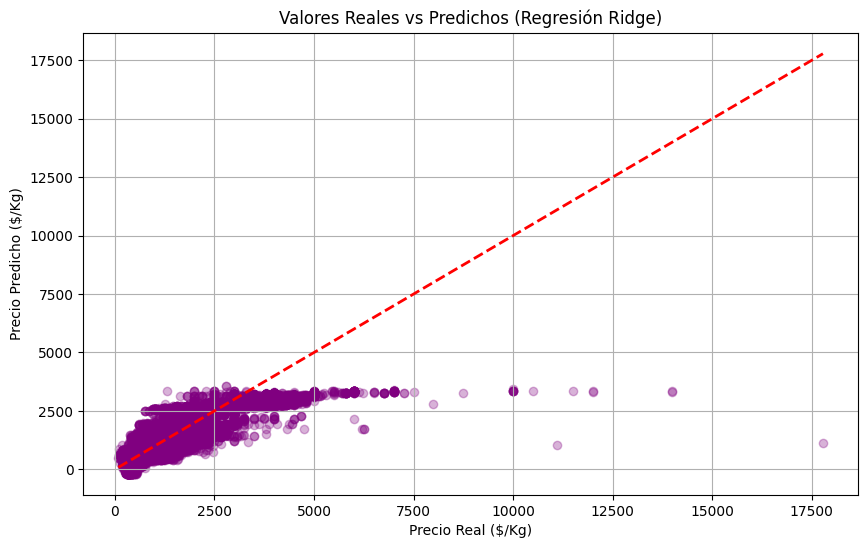

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="purple")
plt.xlabel("Precio Real ($/Kg)")
plt.ylabel("Precio Predicho ($/Kg)")
plt.title("Valores Reales vs Predichos (Regresión Ridge)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2
)
plt.grid(True)
plt.show()